<a href="https://colab.research.google.com/github/1G4S/mechanical-processing/blob/main/SystemWczesnegoOstrzegania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# System wczesnego ostrzegania

1. Konfiguracja

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia stylu
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

2. Definicja funkcji

In [13]:
def build_anomaly_detection_system_xai_full(filepath='/content/dane_obrobka_cnc.csv'):
    print("--- ETAP 4: BUDOWA SYSTEMU DETEKCJI I XAI ---")
    df = pd.read_csv(filepath)

    sensor_features = [
        'Wibracje_Wrzeciona_RMS_g',
        'Pobor_Mocy_Mean_kW',
        'Temp_Narzedzia_Max_C',
        'Temp_Chlodziwa_Mean_C',
        'Cisnienie_Chlodziwa_Min_bar'
    ]

    X_sensors = df[sensor_features].copy()
    X_sensors.fillna(X_sensors.median(), inplace=True)

    # 1. TRENOWANIE ISOLATION FOREST
    print("Trenowanie modelu Isolation Forest...")
    iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
    anomaly_labels = iso_forest.fit_predict(X_sensors)
    df['Anomalia_Systemowa'] = np.where(anomaly_labels == -1, 1, 0)

    # 2. DYNAMICZNA DIAGNOSTYKA ODCHYLEŃ (XAI) Z DODANIEM SZUMU (SIGMA)
    print("Obliczanie rzeczywistych, oczekiwanych wartości oraz szumu maszyny...")

    # Przygotowanie pustych kolumn pod Power BI
    df['Anomalia_Glowny_Parametr'] = "Brak (Norma)"
    df['Anomalia_Wartosc_Rzeczywista'] = np.nan
    df['Anomalia_Wartosc_Oczekiwana'] = np.nan
    df['Anomalia_Szum_Maszyny'] = np.nan      # <--- NOWA KOLUMNA (Sigma)
    df['Anomalia_Odchylenie_ZScore'] = np.nan

    z_scores = X_sensors.apply(zscore)

    # Zdefiniowanie normy: Mediana (Oczekiwana) oraz Odchylenie Standardowe (Szum) z detali bezawaryjnych
    zdrowe_detale = df[df['Anomalia_Systemowa'] == 0][sensor_features]
    expected_values = zdrowe_detale.median()
    noise_values = zdrowe_detale.std()        # <--- OBLICZANIE SZUMU

    anomaly_indices = df[df['Anomalia_Systemowa'] == 1].index

    for idx in anomaly_indices:
        worst_feature = z_scores.loc[idx].abs().idxmax()

        # Zapisanie twardych danych do nowych kolumn
        df.loc[idx, 'Anomalia_Glowny_Parametr'] = worst_feature
        df.loc[idx, 'Anomalia_Wartosc_Rzeczywista'] = df.loc[idx, worst_feature]
        df.loc[idx, 'Anomalia_Wartosc_Oczekiwana'] = expected_values[worst_feature]
        df.loc[idx, 'Anomalia_Szum_Maszyny'] = noise_values[worst_feature] # <--- ZAPIS SZUMU
        df.loc[idx, 'Anomalia_Odchylenie_ZScore'] = z_scores.loc[idx, worst_feature]

    df.to_csv('dane_obrobka_cnc_po_anomaliach.csv', index=False)

    print("Generowanie wizualizacji...")

    unique_causes = df['Anomalia_Glowny_Parametr'].unique()
    palette = {'Brak (Norma)': '#d3d9df'}
    colors = sns.color_palette("Set1", len(unique_causes))

    c_idx = 0
    for cause in unique_causes:
        if cause != 'Brak (Norma)':
            palette[cause] = colors[c_idx]
            c_idx += 1

    df_sorted = df.sort_values('Anomalia_Systemowa')

    # SZEREGI CZASOWE Z OZNACZENIEM AWARII
    features = [
        'Wibracje_Wrzeciona_RMS_g', 'Pobor_Mocy_Mean_kW',
        'Temp_Narzedzia_Max_C', 'Cisnienie_Chlodziwa_Min_bar'
    ]
    titles = [
        'Wibracje Wrzeciona [g]', 'Średni Pobór Mocy [kW]',
        'Temp. Narzędzia [°C]', 'Ciśnienie Chłodziwa [bar]'
    ]

    # Rysowanie 4 wykresów
    fig1, axes1 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    for i, (feat, title) in enumerate(zip(features, titles)):
        ax = axes1[i]
        # Niebieska linia tła
        ax.plot(df.index, df[feat], color='#a8c0d6', alpha=0.7, linewidth=0.8)

        # Pokazanie czerwonego punktu tylko dla winnego parametru
        my_anomalies = df[df['Anomalia_Glowny_Parametr'] == feat]
        ax.scatter(my_anomalies.index, my_anomalies[feat], color='crimson', s=40, zorder=5, label='Wykryta przyczyna')

        ax.set_ylabel(title, fontweight='bold', fontsize=10)
        if i == 0:
            ax.legend(loc='upper right')

    axes1[-1].set_xlabel('Cykl produkcyjny (ID Części)', fontweight='bold', fontsize=12)
    fig1.suptitle('Przebiegi Sensoryczne z Kontekstową Identyfikacją Przyczyn (XAI)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig1.savefig('wykres_1_szeregi_czasowe.png', bbox_inches='tight', dpi=150)

    # ZALEŻNOŚCI 2D (PRZESTRZEŃ CECH)
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

    # Panel A
    sns.scatterplot(
        data=df_sorted, x='Pobor_Mocy_Mean_kW', y='Wibracje_Wrzeciona_RMS_g',
        hue='Anomalia_Glowny_Parametr', palette=palette, alpha=0.9, s=50, edgecolor=None, ax=axes2[0]
    )
    axes2[0].set_title("Wymiar Mechaniczny (Pobór Mocy vs Wibracje)", fontsize=12, pad=10)
    axes2[0].set_xlabel('Średni Pobór Mocy [kW]', fontweight='bold')
    axes2[0].set_ylabel('Wibracje Wrzeciona RMS [g]', fontweight='bold')
    axes2[0].get_legend().remove() # Usuwamy legendę z pierwszego, żeby nie dublować

    # Panel B
    sns.scatterplot(
        data=df_sorted, x='Cisnienie_Chlodziwa_Min_bar', y='Temp_Narzedzia_Max_C',
        hue='Anomalia_Glowny_Parametr', palette=palette, alpha=0.9, s=50, edgecolor=None, ax=axes2[1]
    )
    axes2[1].set_title("Wymiar Termodynamiczny (Ciśnienie vs Temperatura)", fontsize=12, pad=10)
    axes2[1].set_xlabel('Ciśnienie Chłodziwa [bar]', fontweight='bold')
    axes2[1].set_ylabel('Maksymalna Temp. Narzędzia [°C]', fontweight='bold')

    axes2[1].legend(title='Fizyczna przyczyna anomalii', bbox_to_anchor=(1.05, 1), loc='upper left')

    fig2.suptitle('Wielowymiarowa Przestrzeń Decyzyjna Algorytmu Isolation Forest', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    fig2.savefig('wykres_2_przestrzenie_2d.png', bbox_inches='tight', dpi=150)


    print("Zapisano oddzielnie: 'wykres_1_szeregi_czasowe.png' oraz 'wykres_2_przestrzenie_2d.png'.")


    print("--- GENEROWANIE WIZUALIZACJI STUDIÓW PRZYPADKU (CASE STUDIES) ---")

    df = pd.read_csv('/content/dane_obrobka_cnc_po_anomaliach.csv')

    # Zmiana nazw
    feature_names = [
        'Wibracje',
        'Pobór Mocy',
        'Temp. Ostrza',
        'Temp. Chłodziwa',
        'Ciśnienie'
    ]
    # Filtrowanie anomalii i szukanie 3 różnych przyczyn
    anomalies = df[df['Anomalia_Systemowa'] == 1]
    unique_causes = anomalies['Anomalia_Glowny_Parametr'].unique()

    # Wybranie max 3 różnych przyczyn do zobrazowania
    causes_to_plot = unique_causes[:3]

    fig, axes = plt.subplots(1, len(causes_to_plot), figsize=(18, 6), sharey=True)
    if len(causes_to_plot) == 1: axes = [axes] # Zabezpieczenie dla 1 wykresu

    for i, cause in enumerate(causes_to_plot):
        sample_idx = anomalies[anomalies['Anomalia_Glowny_Parametr'] == cause].index[0]
        sample_id = df.loc[sample_idx, 'ID_Czesci']

        # Pobranie odchylenia Z-score dla tego jednego detalu
        sample_zscores = z_scores.loc[sample_idx].values

        # Ustawienie koloru słupków
        colors = ['crimson' if feat == cause else 'steelblue' for feat in sensor_features]

        ax = axes[i]

        bars = ax.barh(feature_names, sample_zscores, color=colors, edgecolor='black', alpha=0.8)

        # Rysowanie strefy normy
        ax.axvspan(-2.5, 2.5, color='green', alpha=0.1, zorder=0)
        ax.axvline(0, color='black', linewidth=1.2, linestyle='--')

        for bar in bars:
            width = bar.get_width()
            x_offset = 0.5 if width > 0 else -0.5
            ha = 'left' if width > 0 else 'right'
            ax.text(width + x_offset, bar.get_y() + bar.get_height()/2,
                    f'{width:+.1f}σ', va='center', ha=ha, fontweight='bold')

        ax.set_title(f"Studium Przypadku {i+1}\n(Detal ID: {sample_id})", fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Odchylenie od normy (Z-score)', fontsize=12)

        max_abs_z = max(abs(sample_zscores)) + 3
        ax.set_xlim(-max_abs_z, max_abs_z)

    plt.suptitle('Profil Wielowymiarowy Wybranych Anomalii (XAI)', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()

    output_filename = 'studia_przypadku_anomalie.png'
    plt.savefig(output_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"GOTOWE! Wykres zapisano jako '{output_filename}'.")

3. Uruchomienie

--- ETAP 4: BUDOWA SYSTEMU DETEKCJI I XAI ---
Trenowanie modelu Isolation Forest...
Obliczanie rzeczywistych, oczekiwanych wartości oraz szumu maszyny...
Generowanie wizualizacji...
Zapisano oddzielnie: 'wykres_1_szeregi_czasowe.png' oraz 'wykres_2_przestrzenie_2d.png'.
--- GENEROWANIE WIZUALIZACJI STUDIÓW PRZYPADKU (CASE STUDIES) ---


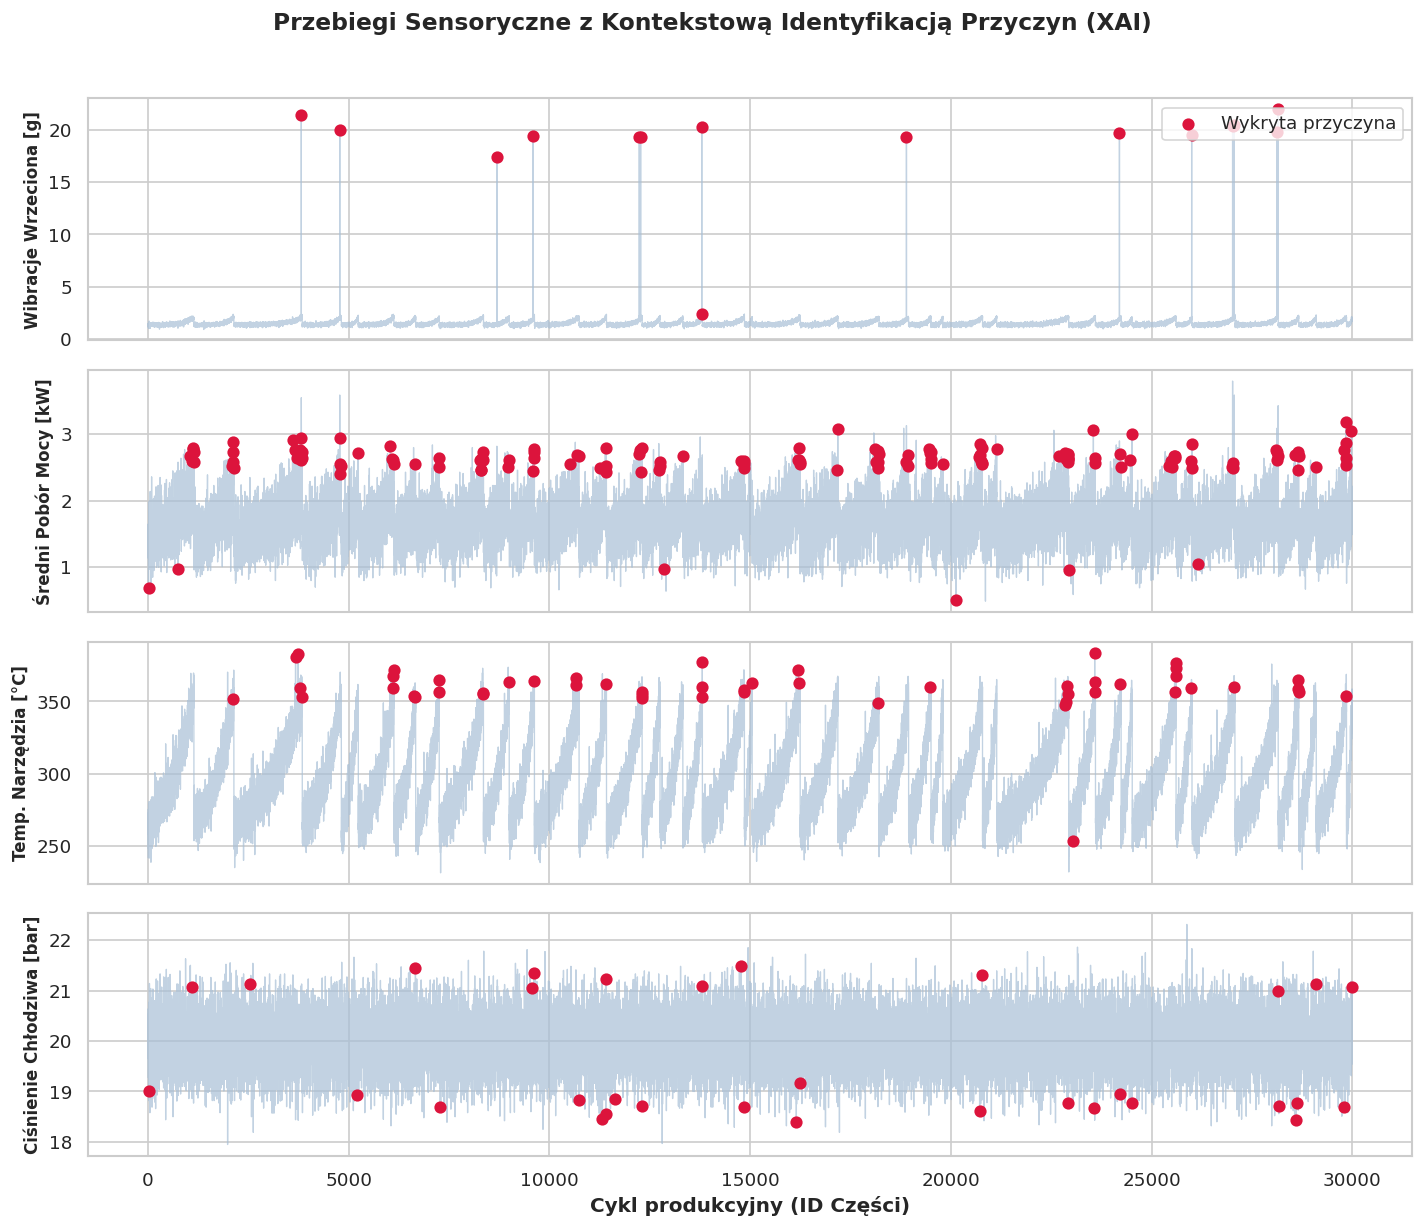

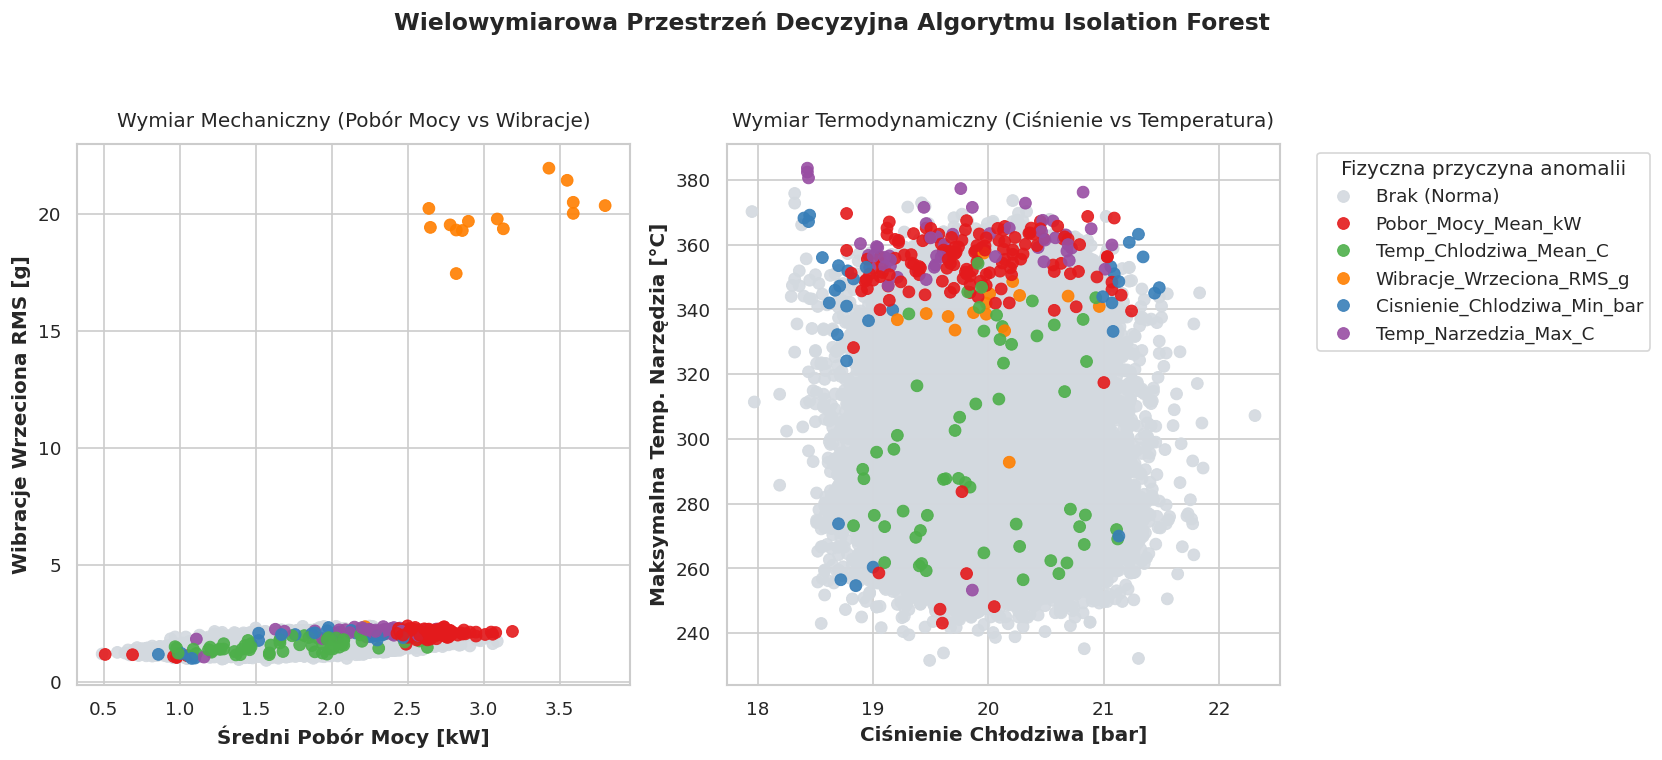

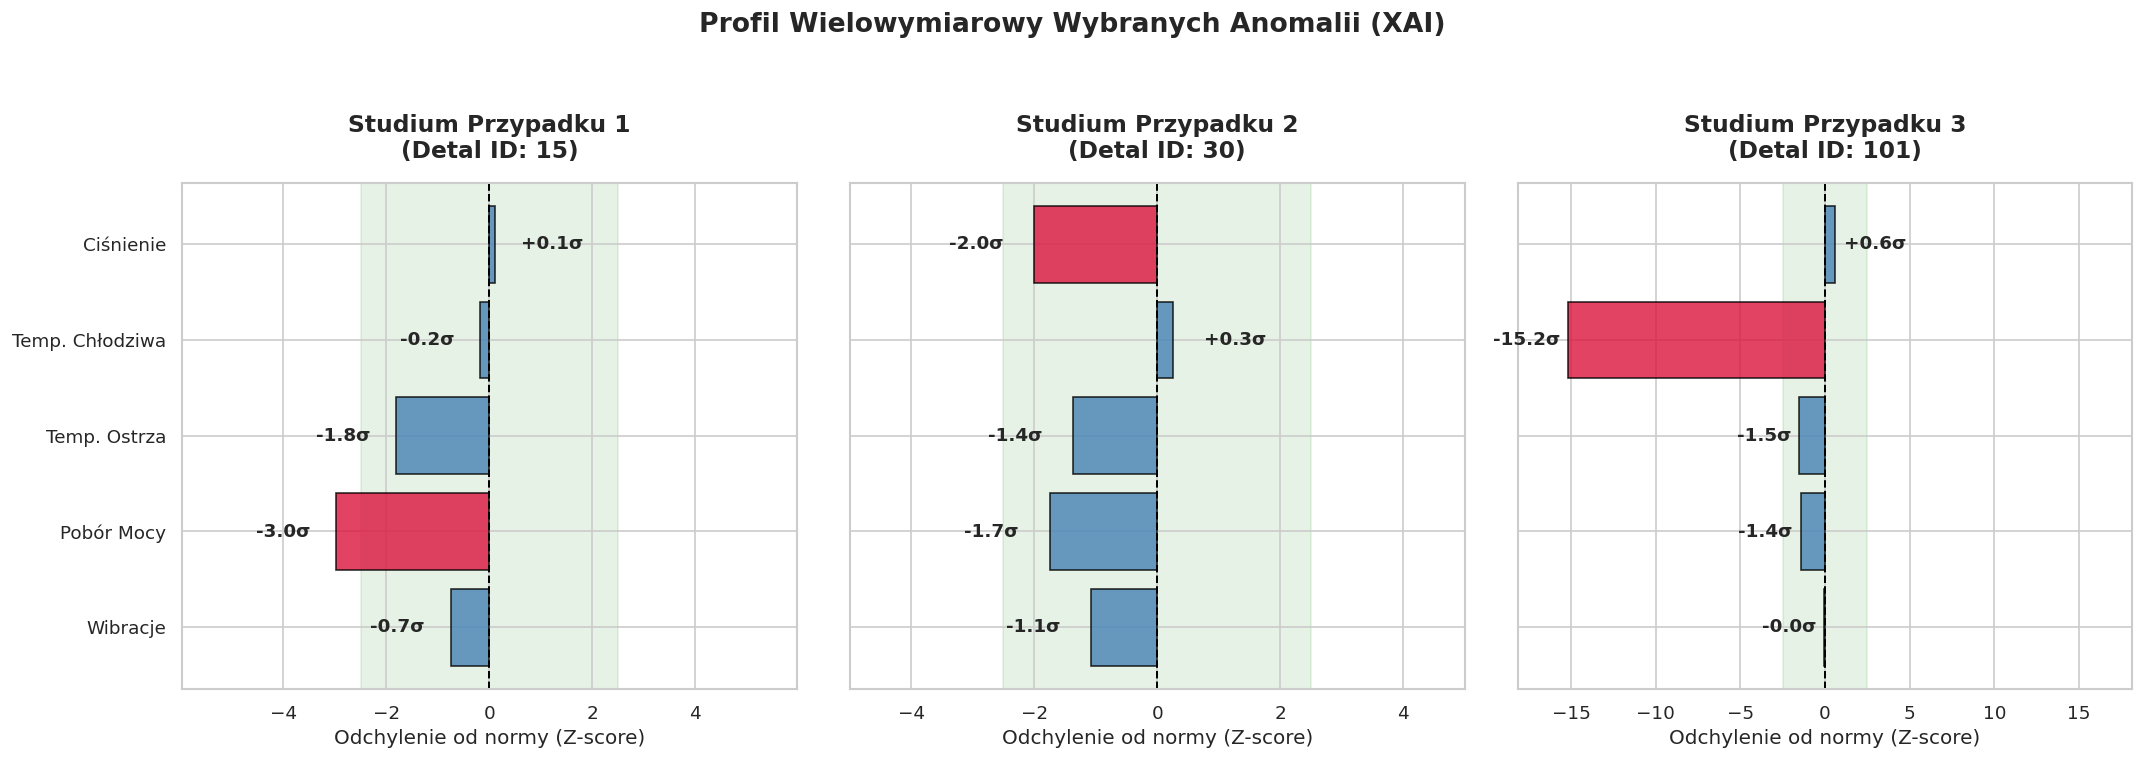

GOTOWE! Wykres zapisano jako 'studia_przypadku_anomalie.png'.


In [14]:

build_anomaly_detection_system_xai_full()